# 2 - COCO YOLO Convolutional Neural Network (PyTorch/ Ultralytics)                                                                          

  After using TensorFlow for the last model which I have been learning to use I found that PyTorch is better equipped to learn YOLO images. This is because TensorFlow lacked loss functions for YOLO which are built into Pytorch and just need combining. So for this network we are going to use Pytorch instead. You can make it even eaiser and higher level using ultralytics wich does have the complete loss function built in. 
  Everything else about the model and network will be very similar if not the same.

  Microsoft Common Objects in Context (MS COCO) is a large-scale benchmark dataset designed to advance object detection, instance segmentation, and image captioning research by focusing on objects in their natural, non-iconic context. Unlike prior datasets that emphasise centered, isolated objects, COCO deliberately collects non-iconic images — scenes where objects appear partially occluded, at varied scales, and amid real-world clutter — making it significantly more challenging than PASCAL VOC or ImageNet. The dataset contains over 330,000 images (more than 200,000 labeled), 1.5 million object instances, 80 object ("thing") categories, 91 stuff categories, and an average of 7.7 instances per image. Annotations were gathered using a three-stage Amazon Mechanical Turk pipeline: category labeling, instance spotting, and pixel-level instance segmentation — totalling over 70,000 worker hours. Each image is annotated with precise bounding boxes and segmentation masks, enabling both detection and localisation tasks. COCO was introduced by Lin et al. (Microsoft Research, 2015) and has since become the standard benchmark for modern object detection architectures including YOLO.

  **Architecture: (Pytorch)** (Not Done Yet but will be in from:)                                                                                                 
  `56×56×1 input → Augmentation → Conv(64, 3×3) → MaxPool(2×2) → Conv(64, 3×3) → MaxPool(2×2) → Flatten → Dense(128, tanh) → Dropout(0.3) → Dense(128,
  tanh) → Dropout(0.3) → Dense(10, softmax)`                                                                                                            
                  
  **Techniques:** (not done yet will be in the form:) TensorFlow/Keras high-level API · Convolutional + max-pooling layers · ReLU + tanh + softmax      
  activations · Dropout regularisation · Sparse categorical cross-entropy loss · Adam optimiser · `validation_split` + `EarlyStopping` to prevent
  overfitting                                                                                                                                           
                  
  **Outputs:** (not done yet will be in the form:) Digits 0–9                                                                             
                                                                                                                                                        
  **Result: ~98.7% test accuracy**                                                                                                                      
  | Metric | Accuracy | Loss |                                                                                                                          
  |--------|----------|------|                                                                                                                          
  | Final training | 97.7% | 0.078 |                                                                                                                    
  | Final validation | 98.6% | 0.047 |
  | Test | 98.7% | 0.042 |                                                                                                                              
  | Train/test gap | -1.0% | |

  Option 1 — Use a pretrained model (easiest)
  from ultralytics import YOLO
  model = YOLO('yolo26n.pt')        # download pretrained weights
  results = model('image.jpg')      # run detection immediately
  Ready to use in 2 lines. Already trained on COCO 80 classes.

  ---
  Option 2 — Fine-tune a pretrained model on your own data
  model = YOLO('yolov8n.pt')        # start from pretrained weights
  model.train(data='mycars.yaml', epochs=50)  # continue training on your dataset
  Takes the pretrained knowledge and specialises it for your specific use case. Much faster than training from scratch.
  If you freeze the backbone and only retrain the detection head:                                                                                                          
  - The backbone (the conv layers that extract features like edges, shapes, textures) stays intact
  - Only the final layers that map features → class predictions get updated                                                                                                
  - Much less forgetting, faster training, needs less data                 
                                                                                                                                                                           
  model = YOLO("yolo11n.pt")
  model.train(data="people.yaml", epochs=50, freeze=10)  # freeze first 10 layers        

  ---
  Option 3 — Train from scratch
  model = YOLO('yolov8n.yaml')      # architecture only, random weights
  model.train(data='coco.yaml', epochs=300)
  Same architecture, no pretrained weights. Slower, needs more data.

  ---
  So Ultralytics is really a framework that wraps PyTorch and gives you:
  - The YOLO architecture already built
  - Training, evaluation, and inference pipelines
  - Dataset handling

# Installing Dependencies
---                                                                                                                                  
  | Package | Purpose |
  |---|---|                                                                                                                                                                
  | `torch` | Core PyTorch library |
  | `torchvision` | Computer vision tools built on top of torch |                                                                                                          
                                                                                                                                                                           
  **`torch`** — everything needed to build and train neural networks:
  - `nn.Module` — base class for all models                                                                                                                                
  - `nn.Conv2d`, `nn.Linear` — layer definitions                                                                                                                           
  - Tensors — PyTorch's equivalent of numpy arrays
  - MPS/GPU acceleration for Apple Silicon                                                                                                                                 
                  
  **`torchvision`** — computer vision tools built on top of `torch`:                                                                                                       
  - Pre-built datasets — COCO, ImageNet, MNIST
  - Pre-trained models — ResNet, VGG, YOLO                                                                                                                                 
  - Image transforms — resize, crop, normalise, augment
  - Utility functions for loading and displaying images                                                                                                                    
                  
  > Other domain-specific libraries follow the same pattern — `torchaudio` for audio/speech, `torchtext` for NLP — each building on top of the core `torch` package.

In [1]:
%pip install --upgrade pip -q
%pip install torch torchvision -q
%pip install ultralytics -q


# --- Import Dependencies ---
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches  

# --- Set Up Dependencies ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # tells pytorch to use mps (Metal Performance Shaders) which is the GPU if available, if not use the CPUs
print(f"PyTorch is using {device}.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PyTorch is using mps.


In [2]:
model = YOLO("yolo26n.pt")
results = model("04D1C682-ADAD-4E07-A1A9-869FB9B0D2B5_1_105_c.jpeg")
print(results)

Boxes = results[0]
for box in Boxes.boxes:
    print(box)

#print(model.model)
print("\n")
model.info(verbose=True, detailed=True)


image 1/1 /Users/joehill/Developer/DeepLearning/5-YOLO-Convolutional-Neural-Network/04D1C682-ADAD-4E07-A1A9-869FB9B0D2B5_1_105_c.jpeg: 640x480 3 persons, 1 couch, 38.4ms
Speed: 1.3ms preprocess, 38.4ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 480)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bott

(122, 2408932, 0, 5.3598848)

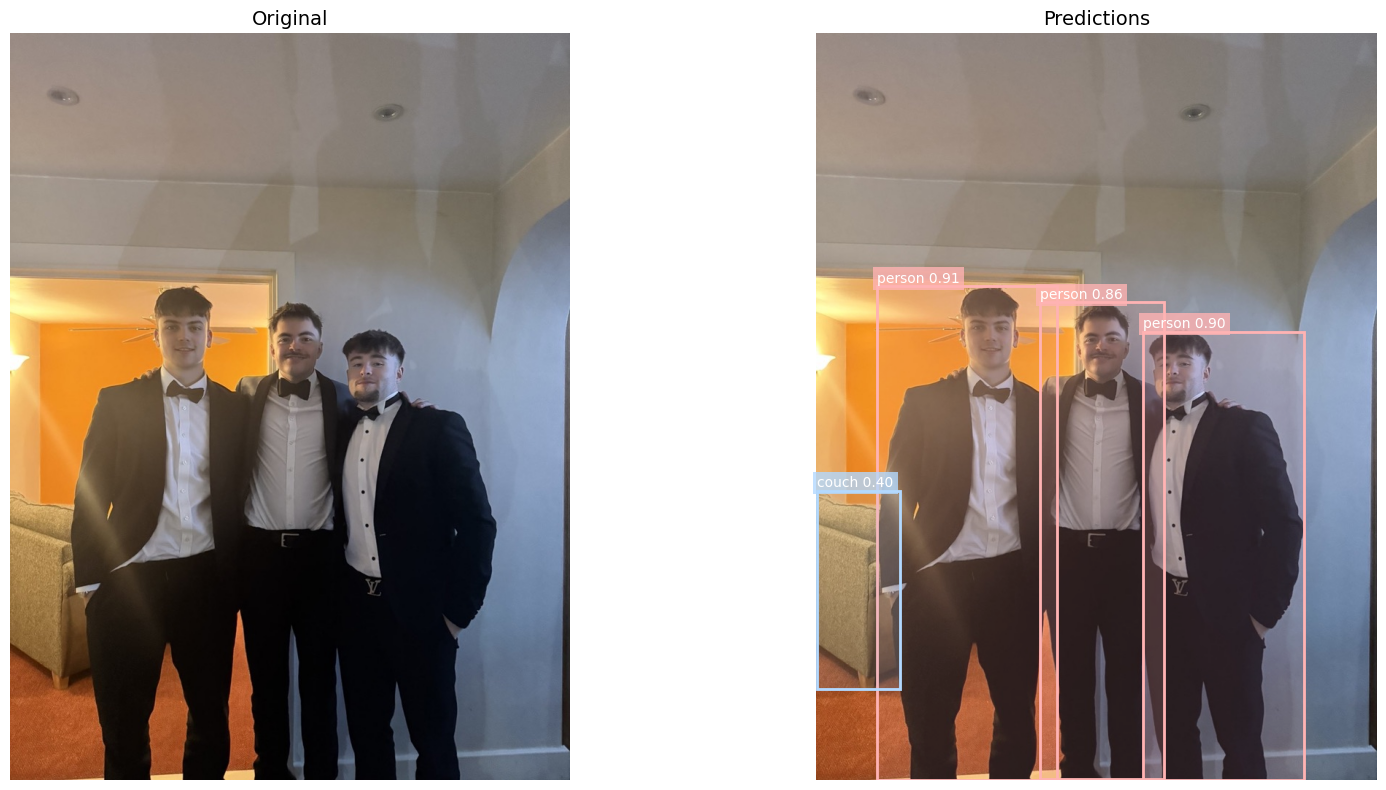

In [3]:
def show_predictions(model, image_path):
    PASTEL_COLORS = [                                                                                                           
        "#FFB3B3", "#FFDDB3", "#FFFCB3", "#B3FFB8", "#B3EEFF",                                                                                                           
        "#B3C8FF", "#D4B3FF", "#FFB3F0", "#FFB3C8", "#B3FFE8",                                                                                                           
        "#E8FFB3", "#FFD9B3", "#B3D9FF", "#F0B3FF", "#B3FFCC",                                                                                                           
    ]                                                                                                                                                                    
                                                                                                                                                                        
    results = model(image_path, verbose=False)                                                                                                                                          
    result = results[0]
    img = result.orig_img[:, :, ::-1]  # BGR to RGB
                                                                                                                                                                        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
                                                                                                                                                                        
    # Original image
    ax1.imshow(img)
    ax1.set_title("Original", fontsize=14)
    ax1.axis("off")                                                                                                                                                      

    # Predictions                                                                                                                                                        
    ax2.imshow(img)
    ax2.set_title("Predictions", fontsize=14)
                                                                                                                                                                        
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()                                                                                                                            
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())
        label = f"{result.names[cls]} {conf:.2f}"                                                                                                                        
        color = PASTEL_COLORS[cls % len(PASTEL_COLORS)]
                                                                                                                                                                        
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,                                                                                                             
                                linewidth=2, edgecolor=color, facecolor=color, alpha=0.15)
        ax2.add_patch(rect)                                                                                                                                              
                
        # Outline with no fill on top for crisp border                                                                                                                   
        rect_border = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=color, facecolor="none")                                                                                  
        ax2.add_patch(rect_border)
                                                                                                                                                                        
        ax2.text(x1, y1 - 5, label, color="white", fontsize=10,                                                                                                          
                bbox=dict(facecolor=color, alpha=0.8, pad=3, edgecolor="none"))
                                                                                                                                                                        
    ax2.axis("off")
    plt.tight_layout()                                                                                                                                                   
    plt.show()  

                                                                                                                                                                           
show_predictions(model, "04D1C682-ADAD-4E07-A1A9-869FB9B0D2B5_1_105_c.jpeg")